In [100]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random 
from datetime import datetime, timedelta


In [101]:
def criar_df(total_iten):
    
    print(f"\nIniciando a geração de {total_iten} registros de vendas...")
    
    produtos = {
        'Laptop Gamer': {'categoria': 'Eletrônicos', 'preco': 7500.00},
        'Mouse Vertical': {'categoria': 'Acessórios', 'preco': 250.00},
        'Teclado Mecânico': {'categoria': 'Acessórios', 'preco': 550.00},
        'Monitor Ultrawide': {'categoria': 'Eletrônicos', 'preco': 2800.00},
        'Cadeira Gamer': {'categoria': 'Móveis', 'preco': 1200.00},
        'Headset 7.1': {'categoria': 'Acessórios', 'preco': 800.00},
        'Placa de Vídeo': {'categoria': 'Hardware', 'preco': 4500.00},
        'SSD 1TB': {'categoria': 'Hardware', 'preco': 600.00}
    }
    lista_nomes_prod = list(produtos.keys())
    
    cidades_estados = {
        'São Paulo': 'SP', 'Rio de Janeiro': 'RJ', 'Belo Horizonte': 'MG',
        'Porto Alegre': 'RS', 'Salvador': 'BA', 'Curitiba': 'PR', 'Fortaleza': 'CE'
    }
    lista_cid = list(cidades_estados.keys())
    
    dados_vendas = []
    data_inicial = datetime(2026,1,1)
    
    for i in range(total_iten):
        nome_prod = random.choice(lista_nomes_prod)
        nome_cidade = random.choice(lista_cid)
        quant_vendida = random.randint(1,11)
        data_pedido = data_inicial + timedelta(days = int(i/5), hours = random.randint(0, 23))

        if nome_prod in ["Mouse Vertical", "Teclado Mecânico"]:
            preco = produtos[nome_prod]["preco"] * np.random.uniform(0.9, 1)
        preco = produtos[nome_prod]["preco"]
        
        categoria = produtos[nome_prod]["categoria"]
        
        dados_vendas.append({
            'ID_Pedido': 1000 + i,
            'Data_Pedido': data_pedido,
            'Nome_Produto': nome_prod,
            'Categoria': categoria,
            'Preco_Unitario': preco,
            'Quantidade': quant_vendida,
            'ID_Cliente': np.random.randint(100, 150),
            'Cidade': nome_cidade,
            'Estado': cidades_estados[nome_cidade]
        })
    print("Geração de dados concluída.\n")
    return pd.DataFrame(dados_vendas)


x = 1000
df = criar_df(x)
df


Iniciando a geração de 1000 registros de vendas...
Geração de dados concluída.



,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
0,1000,2026-01-01 08:00:00,Cadeira Gamer,Móveis,1200.0,1,138,Fortaleza,CE
1,1001,2026-01-01 18:00:00,Laptop Gamer,Eletrônicos,7500.0,8,117,São Paulo,SP
2,1002,2026-01-01 19:00:00,Monitor Ultrawide,Eletrônicos,2800.0,7,136,Curitiba,PR
3,1003,2026-01-01 03:00:00,SSD 1TB,Hardware,600.0,3,117,Belo Horizonte,MG
4,1004,2026-01-01 14:00:00,Mouse Vertical,Acessórios,250.0,5,122,Porto Alegre,RS
...,...,...,...,...,...,...,...,...,...
995,1995,2026-07-19 10:00:00,Placa de Vídeo,Hardware,4500.0,7,111,Porto Alegre,RS
996,1996,2026-07-19 14:00:00,Placa de Vídeo,Hardware,4500.0,5,145,São Paulo,SP
997,1997,2026-07-19 00:00:00,Headset 7.1,Acessórios,800.0,10,125,Porto Alegre,RS
998,1998,2026-07-19 19:00:00,Cadeira Gamer,Móveis,1200.0,3,141,São Paulo,SP


In [102]:
df.describe().round(2)

,ID_Pedido,Data_Pedido,Preco_Unitario,Quantidade,ID_Cliente
count,1000.00,1000,1000.00,1000.00,1000.00
mean,1499.50,2026-04-10 23:13:51.600000,2183.25,5.97,124.79
min,1000.00,2026-01-01 03:00:00,250.00,1.00,100.00
25%,1249.75,2026-02-20 01:30:00,550.00,3.00,113.00
50%,1499.50,2026-04-11 00:00:00,800.00,6.00,124.50
75%,1749.25,2026-05-30 20:00:00,2800.00,9.00,138.00
max,1999.00,2026-07-19 19:00:00,7500.00,11.00,149.00
std,288.82,NaN,2326.90,3.15,14.60


In [103]:
df.dtypes

ID_Pedido                  int64
Data_Pedido       datetime64[us]
Nome_Produto                 str
Categoria                    str
Preco_Unitario           float64
Quantidade                 int64
ID_Cliente                 int64
Cidade                       str
Estado                       str
dtype: object

In [104]:
df["Faturamento"] = df["Preco_Unitario"] * df["Quantidade"]
df.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento
0,1000,2026-01-01 08:00:00,Cadeira Gamer,Móveis,1200.0,1,138,Fortaleza,CE,1200.0
1,1001,2026-01-01 18:00:00,Laptop Gamer,Eletrônicos,7500.0,8,117,São Paulo,SP,60000.0
2,1002,2026-01-01 19:00:00,Monitor Ultrawide,Eletrônicos,2800.0,7,136,Curitiba,PR,19600.0
3,1003,2026-01-01 03:00:00,SSD 1TB,Hardware,600.0,3,117,Belo Horizonte,MG,1800.0
4,1004,2026-01-01 14:00:00,Mouse Vertical,Acessórios,250.0,5,122,Porto Alegre,RS,1250.0


In [105]:
df["Status_Entrega"] = df["Estado"].apply(lambda estado: "Rápido" if estado in ["SP" , "RJ", "MG"] else "Normal")
df.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega
0,1000,2026-01-01 08:00:00,Cadeira Gamer,Móveis,1200.0,1,138,Fortaleza,CE,1200.0,Normal
1,1001,2026-01-01 18:00:00,Laptop Gamer,Eletrônicos,7500.0,8,117,São Paulo,SP,60000.0,Rápido
2,1002,2026-01-01 19:00:00,Monitor Ultrawide,Eletrônicos,2800.0,7,136,Curitiba,PR,19600.0,Normal
3,1003,2026-01-01 03:00:00,SSD 1TB,Hardware,600.0,3,117,Belo Horizonte,MG,1800.0,Rápido
4,1004,2026-01-01 14:00:00,Mouse Vertical,Acessórios,250.0,5,122,Porto Alegre,RS,1250.0,Normal


In [106]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       1000 non-null   int64         
 1   Data_Pedido     1000 non-null   datetime64[us]
 2   Nome_Produto    1000 non-null   str           
 3   Categoria       1000 non-null   str           
 4   Preco_Unitario  1000 non-null   float64       
 5   Quantidade      1000 non-null   int64         
 6   ID_Cliente      1000 non-null   int64         
 7   Cidade          1000 non-null   str           
 8   Estado          1000 non-null   str           
 9   Faturamento     1000 non-null   float64       
 10  Status_Entrega  1000 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(3), str(5)
memory usage: 86.1 KB


In [107]:
top_10_prod = df.groupby(df["Nome_Produto"])["Quantidade"].sum().sort_values(ascending=False).head(10)
top_10_prod

Nome_Produto
SSD 1TB              836
Mouse Vertical       776
Placa de Vídeo       770
Headset 7.1          756
Monitor Ultrawide    756
Cadeira Gamer        707
Teclado Mecânico     696
Laptop Gamer         676
Name: Quantidade, dtype: int64

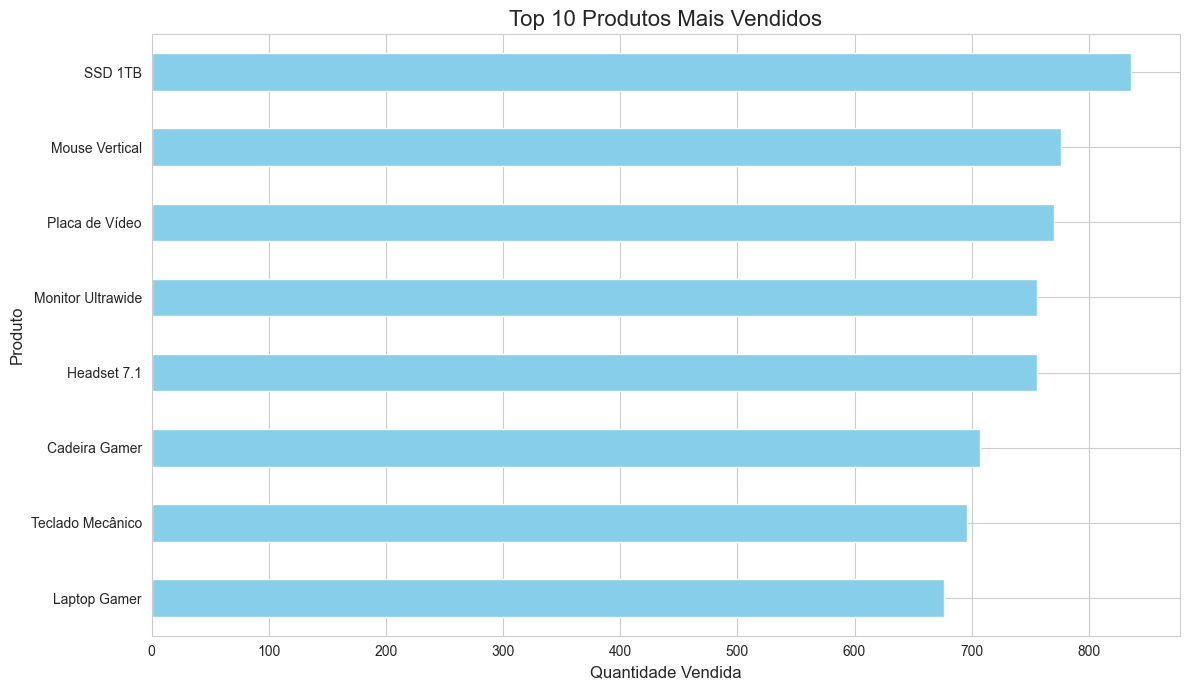

In [108]:
sns.set_style("whitegrid")
plt.figure(figsize=(12,7))
top_10_prod.sort_values().plot(kind="barh", color="skyblue")
plt.title('Top 10 Produtos Mais Vendidos', fontsize = 16)
plt.xlabel('Quantidade Vendida', fontsize = 12)
plt.ylabel('Produto', fontsize = 12)

# Exibe o gráfico
plt.tight_layout()
plt.show()

In [109]:
df.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega
0,1000,2026-01-01 08:00:00,Cadeira Gamer,Móveis,1200.0,1,138,Fortaleza,CE,1200.0,Normal
1,1001,2026-01-01 18:00:00,Laptop Gamer,Eletrônicos,7500.0,8,117,São Paulo,SP,60000.0,Rápido
2,1002,2026-01-01 19:00:00,Monitor Ultrawide,Eletrônicos,2800.0,7,136,Curitiba,PR,19600.0,Normal
3,1003,2026-01-01 03:00:00,SSD 1TB,Hardware,600.0,3,117,Belo Horizonte,MG,1800.0,Rápido
4,1004,2026-01-01 14:00:00,Mouse Vertical,Acessórios,250.0,5,122,Porto Alegre,RS,1250.0,Normal


In [110]:
df["Mês"] = df["Data_Pedido"].dt.to_period("M")
df.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega,Mês
0,1000,2026-01-01 08:00:00,Cadeira Gamer,Móveis,1200.0,1,138,Fortaleza,CE,1200.0,Normal,2026-01
1,1001,2026-01-01 18:00:00,Laptop Gamer,Eletrônicos,7500.0,8,117,São Paulo,SP,60000.0,Rápido,2026-01
2,1002,2026-01-01 19:00:00,Monitor Ultrawide,Eletrônicos,2800.0,7,136,Curitiba,PR,19600.0,Normal,2026-01
3,1003,2026-01-01 03:00:00,SSD 1TB,Hardware,600.0,3,117,Belo Horizonte,MG,1800.0,Rápido,2026-01
4,1004,2026-01-01 14:00:00,Mouse Vertical,Acessórios,250.0,5,122,Porto Alegre,RS,1250.0,Normal,2026-01


In [111]:
fat_mensal = df.groupby("Mês")["Faturamento"].sum().sort_values(ascending=False)
fat_mensal

Mês
2026-06    2488450.0
2026-05    2082550.0
2026-01    2059450.0
2026-02    1942000.0
2026-03    1756300.0
2026-04    1689150.0
2026-07    1165500.0
Freq: M, Name: Faturamento, dtype: float64

In [112]:
fat_mensal.index = fat_mensal.index.to_timestamp().strftime("%Y-%m")
fat_mensal

Mês
2026-06    2488450.0
2026-05    2082550.0
2026-01    2059450.0
2026-02    1942000.0
2026-03    1756300.0
2026-04    1689150.0
2026-07    1165500.0
Name: Faturamento, dtype: float64

In [113]:
fat_mensal.map('R$ {:,.2f}'.format)

Mês
2026-06    R$ 2,488,450.00
2026-05    R$ 2,082,550.00
2026-01    R$ 2,059,450.00
2026-02    R$ 1,942,000.00
2026-03    R$ 1,756,300.00
2026-04    R$ 1,689,150.00
2026-07    R$ 1,165,500.00
Name: Faturamento, dtype: str

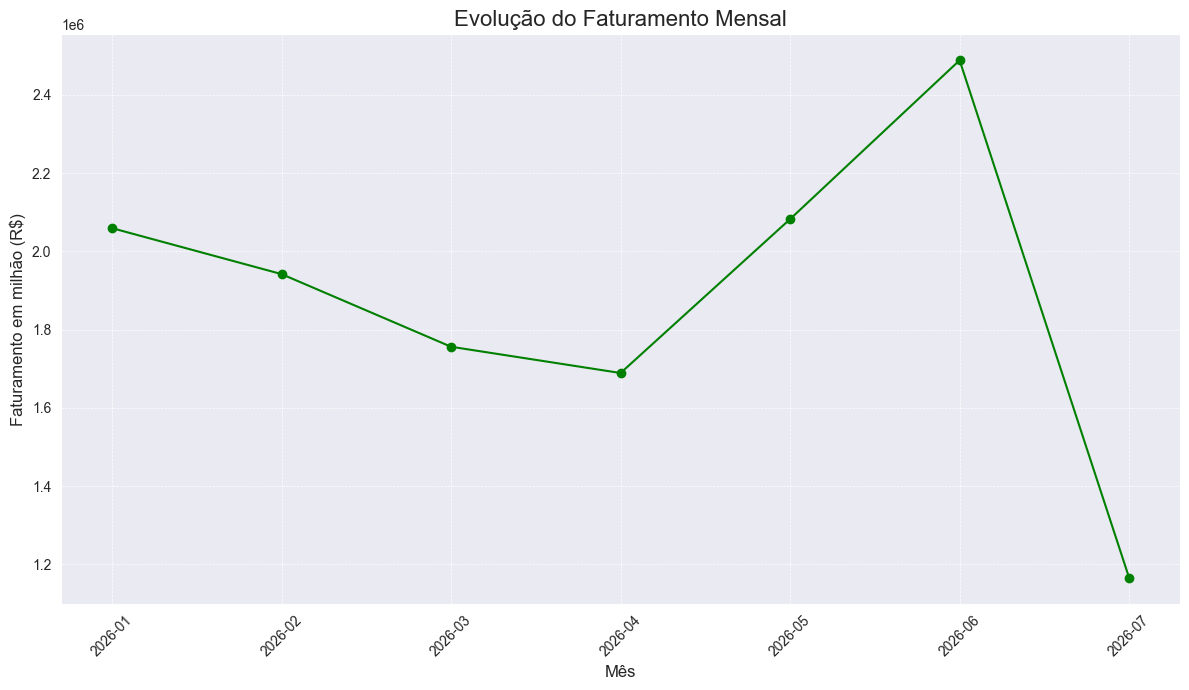

In [117]:
sns.set_style("darkgrid")
plt.figure(figsize=(12,7))
fat_mensal.sort_index().plot(kind="line", marker="o", linestyle="-", color="green")
plt.title('Evolução do Faturamento Mensal', fontsize = 16)

# Define o rótulo do eixo X
plt.xlabel('Mês', fontsize = 12)

# Define o rótulo do eixo Y
plt.ylabel('Faturamento em milhão (R$)', fontsize = 12)

# Rotaciona os valores do eixo X em 45 graus para melhor visualização
plt.xticks(rotation = 45)

# Adiciona uma grade com estilo tracejado e linhas finas
plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5)

# Ajusta automaticamente os elementos para evitar sobreposição
plt.tight_layout()

# Exibe o gráfico
plt.show()

In [118]:
df.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega,Mês
0,1000,2026-01-01 08:00:00,Cadeira Gamer,Móveis,1200.0,1,138,Fortaleza,CE,1200.0,Normal,2026-01
1,1001,2026-01-01 18:00:00,Laptop Gamer,Eletrônicos,7500.0,8,117,São Paulo,SP,60000.0,Rápido,2026-01
2,1002,2026-01-01 19:00:00,Monitor Ultrawide,Eletrônicos,2800.0,7,136,Curitiba,PR,19600.0,Normal,2026-01
3,1003,2026-01-01 03:00:00,SSD 1TB,Hardware,600.0,3,117,Belo Horizonte,MG,1800.0,Rápido,2026-01
4,1004,2026-01-01 14:00:00,Mouse Vertical,Acessórios,250.0,5,122,Porto Alegre,RS,1250.0,Normal,2026-01


In [123]:
vendas_estado = df.groupby("Estado")["Faturamento"].sum().sort_values(ascending=False)
vendas_estado

Estado
RS    2257650.0
MG    2020800.0
RJ    1979150.0
PR    1961950.0
CE    1812900.0
BA    1734200.0
SP    1416750.0
Name: Faturamento, dtype: float64

In [127]:
vendas_estado.map(lambda x: "R$ {:,.2f}".format(x).replace(",", "X").replace(".", ",").replace("X", "."))


Estado
RS    R$ 2.257.650,00
MG    R$ 2.020.800,00
RJ    R$ 1.979.150,00
PR    R$ 1.961.950,00
CE    R$ 1.812.900,00
BA    R$ 1.734.200,00
SP    R$ 1.416.750,00
Name: Faturamento, dtype: str

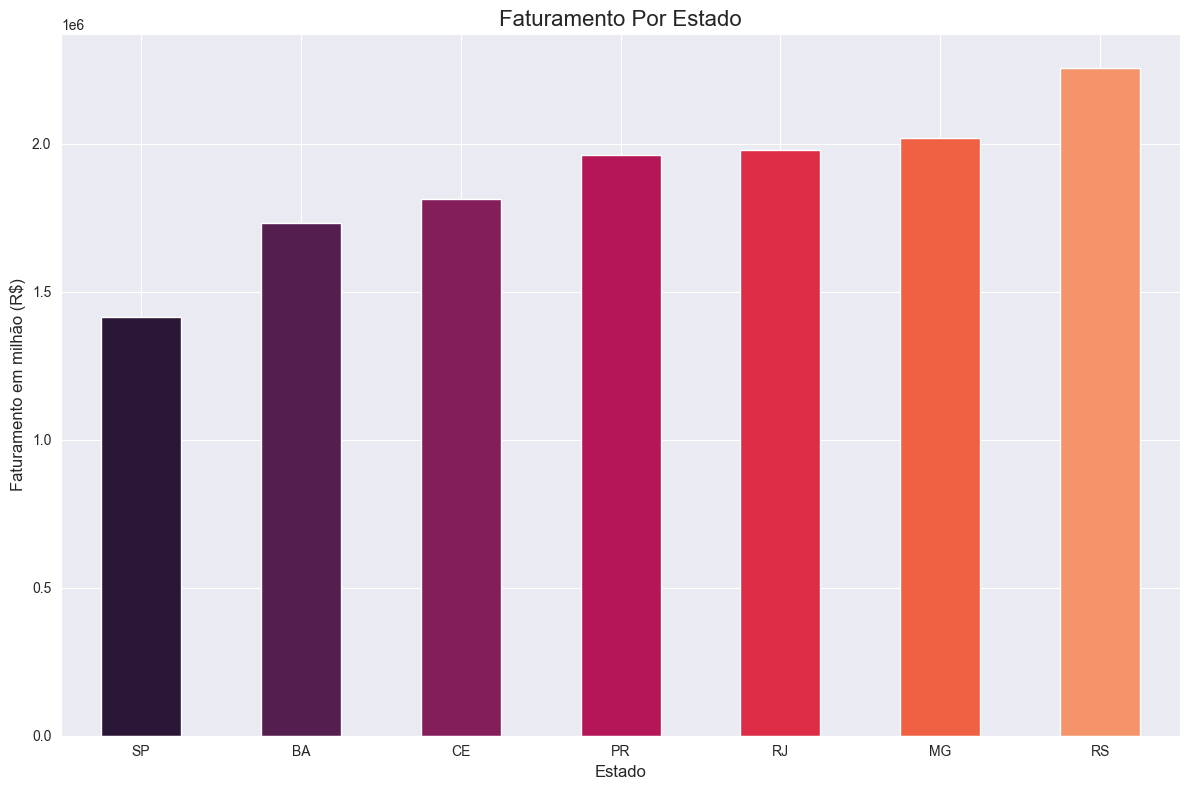

In [138]:
sns.set_style("darkgrid")
plt.figure(figsize=(12,8))
vendas_estado.sort_values().plot(kind="bar", color=sns.color_palette("rocket", 8))

plt.title('Faturamento Por Estado', fontsize = 16)

# Define o rótulo do eixo X
plt.xlabel('Estado', fontsize = 12)

# Define o rótulo do eixo Y
plt.ylabel('Faturamento em milhão (R$)', fontsize = 12)

# Mantém os rótulos do eixo X na horizontal (sem rotação)
plt.xticks(rotation = 0)

# Ajusta automaticamente os elementos do gráfico para evitar sobreposição
plt.tight_layout()

# Exibe o gráfico
plt.show()

In [139]:
df.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega,Mês
0,1000,2026-01-01 08:00:00,Cadeira Gamer,Móveis,1200.0,1,138,Fortaleza,CE,1200.0,Normal,2026-01
1,1001,2026-01-01 18:00:00,Laptop Gamer,Eletrônicos,7500.0,8,117,São Paulo,SP,60000.0,Rápido,2026-01
2,1002,2026-01-01 19:00:00,Monitor Ultrawide,Eletrônicos,2800.0,7,136,Curitiba,PR,19600.0,Normal,2026-01
3,1003,2026-01-01 03:00:00,SSD 1TB,Hardware,600.0,3,117,Belo Horizonte,MG,1800.0,Rápido,2026-01
4,1004,2026-01-01 14:00:00,Mouse Vertical,Acessórios,250.0,5,122,Porto Alegre,RS,1250.0,Normal,2026-01


In [160]:
fat_categoria = df.groupby("Categoria")["Faturamento"].sum().round(2)
fat_categoria

Categoria
Acessórios     1181600.0
Eletrônicos    7186800.0
Hardware       3966600.0
Móveis          848400.0
Name: Faturamento, dtype: float64

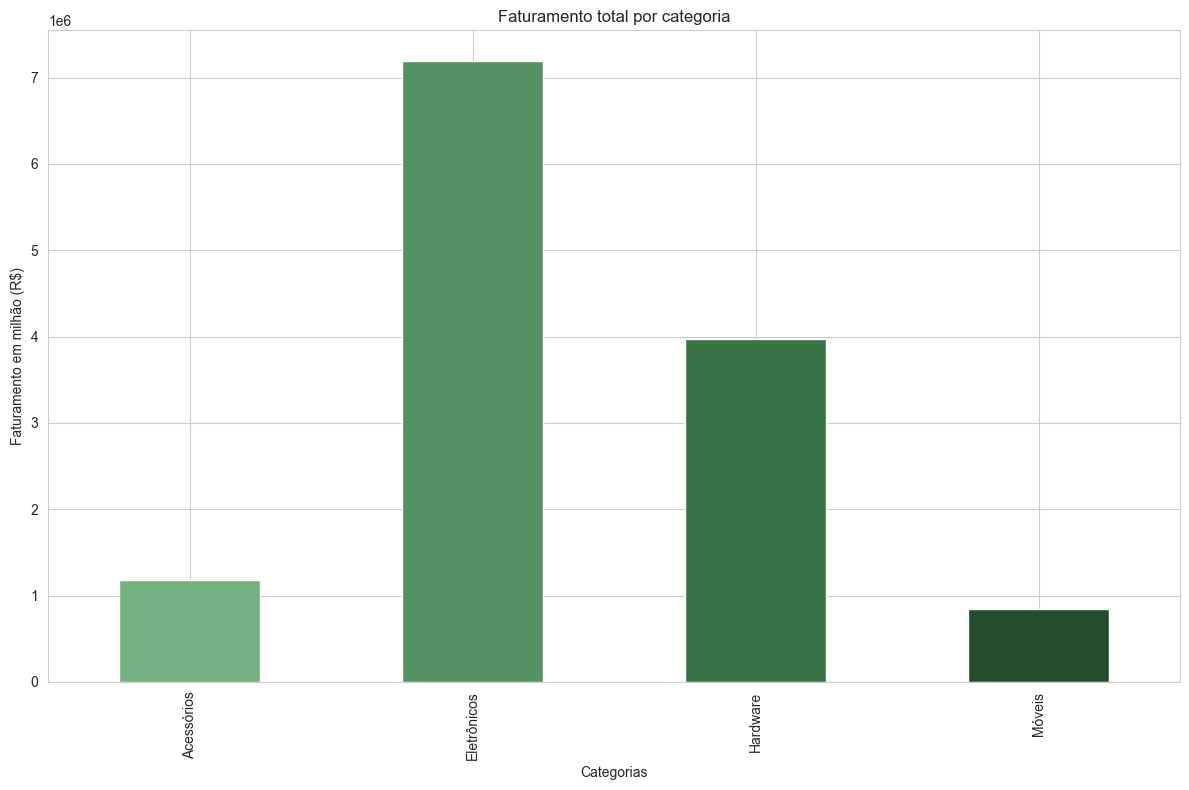

In [159]:
sns.set_style("whitegrid")
plt.figure(figsize=(12,8))
fat_categoria.plot(kind="bar", color = sns.cubehelix_palette(start=2, rot=0, dark=0, light=.60))
plt.title("Faturamento total por categoria")
plt.xlabel("Categorias")
plt.ylabel("Faturamento em milhão (R$)")
plt.tight_layout()
plt.show()